##                                     **LOAD DATA**

In [141]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"c:\Users\dell\Downloads\Afficionado Coffee Roasters.csv")


In [104]:
df.head(10)

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,07:06:11 AM,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,07:08:56 AM,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,07:14:04 AM,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,07:20:24 AM,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,07:22:41 AM,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
5,6,2025,07:22:41 AM,1,5,Lower Manhattan,77,3.00,Bakery,Scone,Oatmeal Scone
6,7,2025,07:25:49 AM,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
7,8,2025,07:33:34 AM,2,5,Lower Manhattan,28,2.00,Coffee,Gourmet brewed coffee,Columbian Medium Roast Sm
8,9,2025,07:39:13 AM,1,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso,Latte Rg
9,10,2025,07:39:34 AM,2,5,Lower Manhattan,58,3.50,Drinking Chocolate,Hot chocolate,Dark chocolate Rg


**Data Validation Checklist**

In [43]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 12.5+ MB
None


In [42]:
# Check invalid timestamps
invalid_times = df['transaction_time'].isnull().sum()
print(f"Invalid timestamps: {invalid_times}")

Invalid timestamps: 0


In [43]:
missing_values = df.isnull().sum()
print(missing_values)

transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
revenue             0
hour                0
day_of_week         0
time_bucket         0
week_part           0
week_par            0
dtype: int64


In [62]:
duplicate_ids = df['transaction_id'].duplicated().sum()
print(f"Duplicate transaction IDs: {duplicate_ids}")

Duplicate transaction IDs: 0


In [45]:
# Positive Quantities
invalid_qty = (df['transaction_qty'] <= 0).sum()
print(f"Invalid quantities: {invalid_qty}")
df = df[df['transaction_qty'] > 0]

Invalid quantities: 0


In [46]:
# Positive Prices
invalid_price = (df['unit_price'] <= 0).sum()
print(f"Invalid prices: {invalid_price}")
df = df[df['unit_price'] > 0]

Invalid prices: 0


**Feature Engineering (Temporal)**

In [142]:
#Revenue per Transaction
df['revenue'] = df['transaction_qty'] * df['unit_price']

In [143]:
import pandas as pd
import numpy as np

# Convert transaction_time to datetime.time
if isinstance(df['transaction_time'].iloc[0], str):
    df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%I:%M:%S %p').dt.time

# Function to assign dates within the year
def assign_dates(year, n):
    # Number of days in the year
    days_in_year = 366 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 365
    # Repeat dates if n > days_in_year
    day_numbers = np.arange(n) % days_in_year
    return pd.to_datetime(f'{year}-01-01') + pd.to_timedelta(day_numbers, unit='D')

# Assign dates using the function (assuming all rows are for the same year, 2025)
year = 2025
n = len(df)
df['date'] = assign_dates(year, n)

# Combine with transaction_time
df['transaction_datetime'] = df.apply(
    lambda row: pd.Timestamp.combine(row['date'], row['transaction_time']),
    axis=1
)

# Extract hour (0-23)
df['hour'] = df['transaction_datetime'].dt.hour

# Day of week
df['day_of_week'] = df['transaction_datetime'].dt.day_name()


# Drop intermediate 'date' if you want
df.drop(columns=['date'], inplace=True)


print(df.head())

   transaction_id  year transaction_time  transaction_qty  store_id  \
0               1  2025         07:06:11                2         5   
1               2  2025         07:08:56                2         5   
2               3  2025         07:14:04                2         5   
3               4  2025         07:20:24                1         5   
4               5  2025         07:22:41                2         5   

    store_location  product_id  unit_price    product_category  \
0  Lower Manhattan          32         3.0              Coffee   
1  Lower Manhattan          57         3.1                 Tea   
2  Lower Manhattan          59         4.5  Drinking Chocolate   
3  Lower Manhattan          22         2.0              Coffee   
4  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  revenue  \
0  Gourmet brewed coffee                  Ethiopia Rg      6.0   
1        Brewed Chai tea     Spicy Eye Opene

In [144]:
#Time Buckets
def get_time_bucket(hour):
    if 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 16:
        return 'Afternoon'
    elif 17 <= hour <= 21:
        return 'Evening'
    else:
        return 'Late Hours'

df['time_bucket'] = df['hour'].apply(get_time_bucket)

In [111]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,transaction_datetime,hour,day_of_week,time_bucket
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2025-01-01 07:06:11,7,Wednesday,Morning
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2025-01-02 07:08:56,7,Thursday,Morning
2,3,2025,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,2025-01-03 07:14:04,7,Friday,Morning
3,4,2025,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,2025-01-04 07:20:24,7,Saturday,Morning
4,5,2025,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2025-01-05 07:22:41,7,Sunday,Morning


**Sales Trend Analysis**

transaction_datetime
2025-01-01    1860.50
2025-01-02    1951.53
2025-01-03    1928.38
2025-01-04    1917.38
2025-01-05    1873.47
Name: revenue, dtype: float64


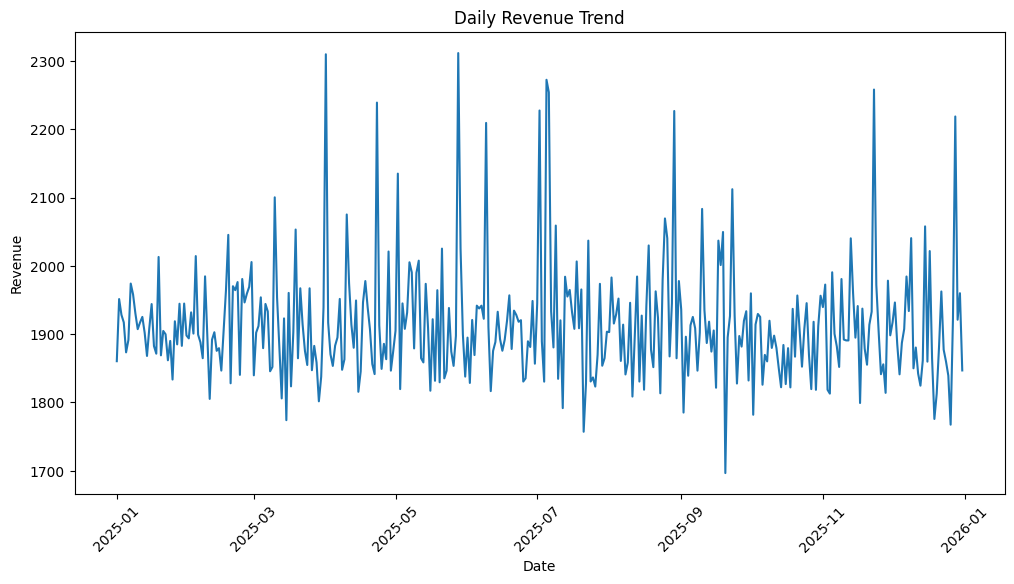

In [145]:
#Daily Revenue Trends

# Daily revenue aggregation using existing transaction_datetime
daily_revenue = df.groupby(df['transaction_datetime'].dt.date)['revenue'].sum()

print(daily_revenue.head())

# Plot Daily Revenue Trend
plt.figure(figsize=(12,6))
plt.plot(daily_revenue.index, daily_revenue.values)
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Weekly Aggregation of Revenue and Transactions
weekly = df.set_index('transaction_datetime').resample('W').agg({
    'revenue':'sum',
    'transaction_id':'count'
})

plt.figure(figsize=(10,5))
plt.plot(weekly.index, weekly['revenue'], marker='o', label='Revenue')
plt.plot(weekly.index, weekly['transaction_id'], marker='o', label='Transactions')
plt.legend()
plt.title("Weekly Revenue & Transactions")
plt.xlabel("Week")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

In [140]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,hour,day_of_week,time_bucket
transaction_datetime,,,,,,,,,,,,,,,
2025-01-01 07:06:11,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,7,Wednesday,Morning
2025-01-02 07:08:56,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Thursday,Morning
2025-01-03 07:14:04,3,2025,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,7,Friday,Morning
2025-01-04 07:20:24,4,2025,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,7,Saturday,Morning
2025-01-05 07:22:41,5,2025,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Sunday,Morning


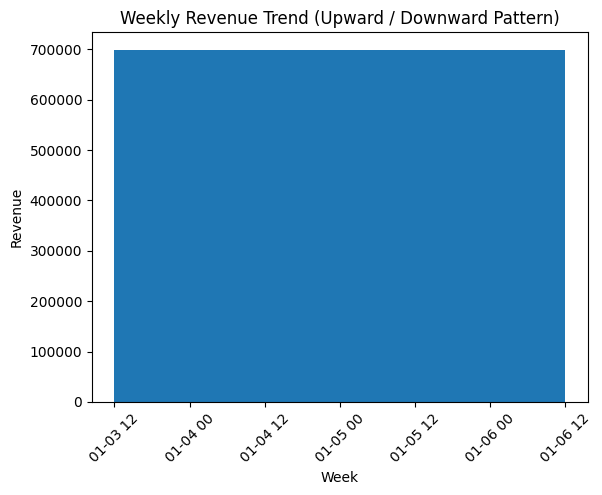

In [18]:
# Identification of upward/downward patterns

weekly_revenue = df.resample('W', on='transaction_time')['revenue'].sum()
down_weeks = weekly_revenue[weekly_revenue.diff() < 0]
plt.bar(weekly_revenue.index, weekly_revenue.values, width=3)

# Mark downward dates
for date, value in down_weeks.items():
    plt.text(date, value, '↓', ha='center')

plt.xlabel("Week")
plt.ylabel("Revenue")
plt.title("Weekly Revenue Trend (Upward / Downward Pattern)")
plt.xticks(rotation=45)

plt.show()

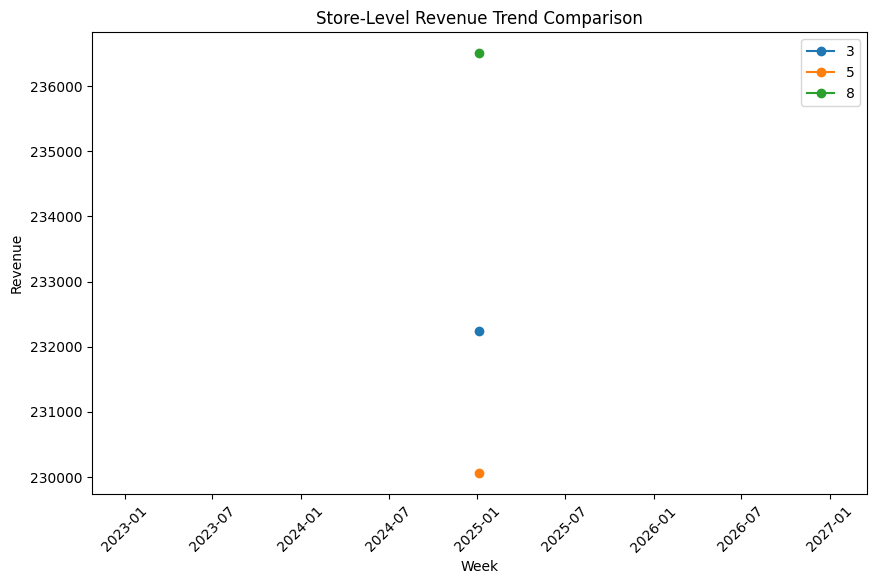

In [19]:
 #Store-level trend comparison
# Add 'date' column to the DataFrame

store_weekly = df.groupby([
    'store_id',
    pd.Grouper(key='transaction_time', freq='W')
])['revenue'].sum().reset_index()
plt.figure(figsize=(10,6))

for store in store_weekly['store_id'].unique():
    data = store_weekly[store_weekly['store_id'] == store]
    plt.plot(data['transaction_time'], data['revenue'], marker='o', label=store)

plt.xlabel("Week")
plt.ylabel("Revenue")
plt.title("Store-Level Revenue Trend Comparison")
plt.legend()

plt.xticks(rotation=45)
plt.show()

**Day-of-Week Performance** **Analysis**

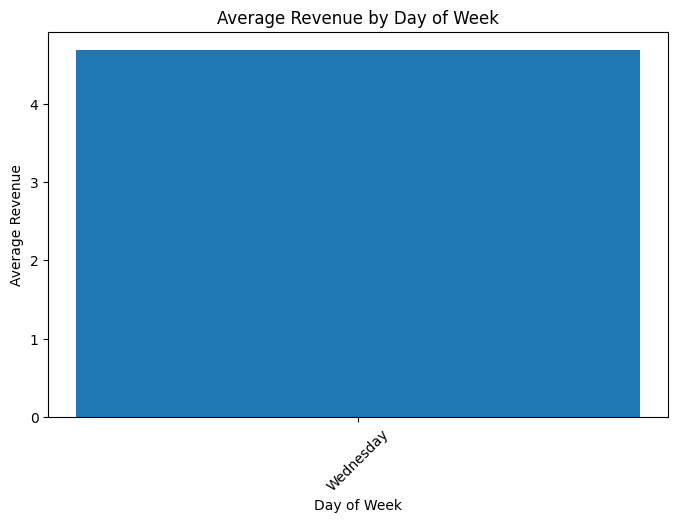

In [20]:
#Average Revenue by Day of Week
import pandas as pd
import matplotlib.pyplot as plt

# Convert to datetime
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

# Extract day of week
df['day_of_week'] = df['transaction_time'].dt.day_name()

# Calculate average revenue
avg_revenue_day = df.groupby('day_of_week')['revenue'].mean()

# Ensure all days appear on x-axis
days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_revenue_day = avg_revenue_day.reindex(days)

# Plot bar graph
plt.figure(figsize=(8,5))

plt.bar(days, avg_revenue_day)

plt.xlabel("Day of Week")
plt.ylabel("Average Revenue")
plt.title("Average Revenue by Day of Week")

plt.xticks(rotation=45)

plt.show()

day_of_week
Monday            NaN
Tuesday           NaN
Wednesday    149116.0
Thursday          NaN
Friday            NaN
Saturday          NaN
Sunday            NaN
Name: transaction_id, dtype: float64


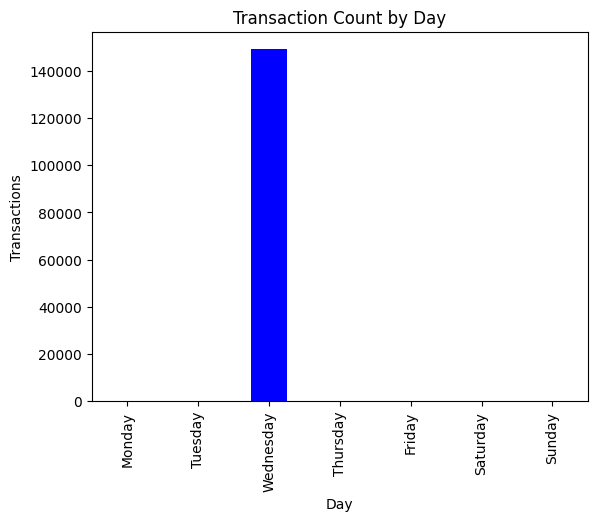

In [21]:
#Average Transaction Count by Day
avg_transactions = df.groupby('day_of_week')['transaction_id'].count().reindex(days)
print(avg_transactions)

#Validation
avg_transactions.plot(kind='bar',color='b', title='Transaction Count by Day')
plt.xlabel("Day")
plt.ylabel("Transactions")
plt.show()

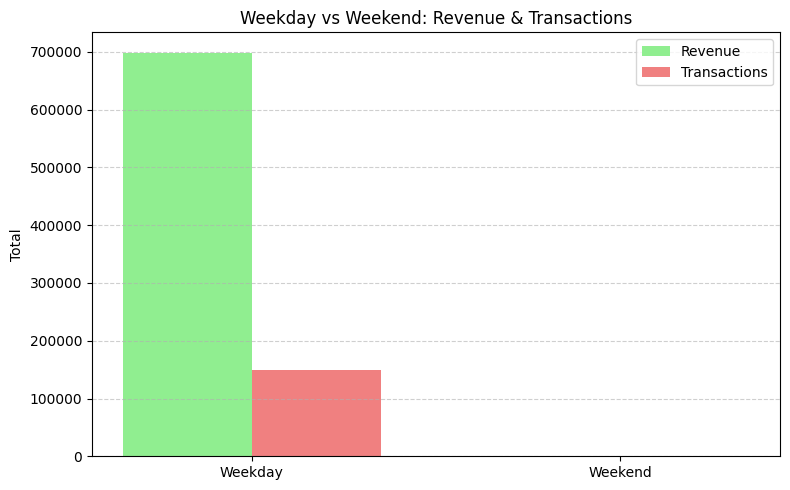

In [22]:
#• Weekday vs weekend comparison
import numpy as np

# Weekday vs Weekend column
df['week_part'] = df['transaction_time'].dt.dayofweek.apply(lambda x: 'Weekday' if x < 5 else 'Weekend')

# Aggregate totals
transactions = df.groupby('week_part')['transaction_id'].count()
revenue = df.groupby('week_part')['revenue'].sum()

# Ensure both 'Weekday' and 'Weekend' are present, fill missing with 0
index_order = ['Weekday', 'Weekend']
transactions = transactions.reindex(index_order, fill_value=0)
revenue = revenue.reindex(index_order, fill_value=0)

# Prepare plot values
week_parts = ['Weekday', 'Weekend']
transaction_values = [transactions['Weekday'], transactions['Weekend']]
revenue_values = [revenue['Weekday'], revenue['Weekend']]

x = np.arange(len(week_parts))
bar_width = 0.35

plt.figure(figsize=(8,5))

# Revenue bars
plt.bar(x - bar_width/2, revenue_values, width=bar_width, color='lightgreen', label='Revenue')

# Transaction bars
plt.bar(x + bar_width/2, transaction_values, width=bar_width, color='lightcoral', label='Transactions')

plt.xticks(x, week_parts)
plt.ylabel('Total')
plt.title('Weekday vs Weekend: Revenue & Transactions')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

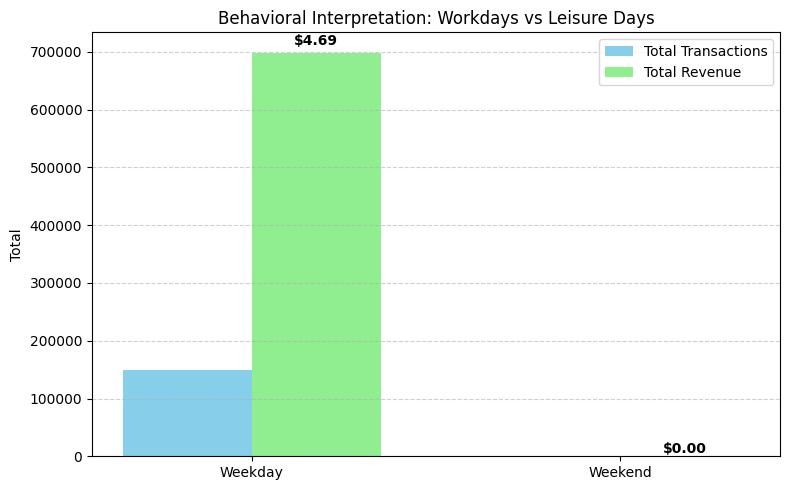

In [23]:
# Behavioral interpretation (workdays vs leisure days)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure datetime
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

# Weekday vs Weekend column
df['week_par'] = df['transaction_time'].dt.dayofweek.apply(lambda x: 'Weekday' if x < 5 else 'Weekend')

# Aggregate totals
transactions = df.groupby('week_par')['transaction_id'].count()
revenue = df.groupby('week_par')['revenue'].sum()

# Ensure both 'Weekday' and 'Weekend' are present, fill missing with 0
index_order = ['Weekday', 'Weekend']
transactions = transactions.reindex(index_order, fill_value=0)
revenue = revenue.reindex(index_order, fill_value=0)

# Calculate average transaction value after reindexing
avg_transaction_value = revenue / transactions  # average per transaction
# Handle potential division by zero if transactions are 0 for a category
avg_transaction_value = avg_transaction_value.replace([np.inf, -np.inf], 0).fillna(0)

# Prepare plot values
week_parts = ['Weekday', 'Weekend']
transaction_values = [transactions['Weekday'], transactions['Weekend']]
revenue_values = [revenue['Weekday'], revenue['Weekend']]
avg_values = [avg_transaction_value['Weekday'], avg_transaction_value['Weekend']]

x = np.arange(len(week_parts))
bar_width = 0.35

plt.figure(figsize=(8,5))

# Plot bars for transactions
plt.bar(x - bar_width/2, transaction_values, width=bar_width, color='skyblue', label='Total Transactions')

# Plot bars for revenue
plt.bar(x + bar_width/2, revenue_values, width=bar_width, color='lightgreen', label='Total Revenue')

# Annotate average transaction value on top of bars
for i in range(len(week_parts)):
    plt.text(x[i] + bar_width/2, revenue_values[i] + revenue_values[i]*0.01, f"${avg_values[i]:.2f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(x, week_parts)
plt.ylabel('Total')
plt.title('Behavioral Interpretation: Workdays vs Leisure Days')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Time-of-Day Demand Analysis**

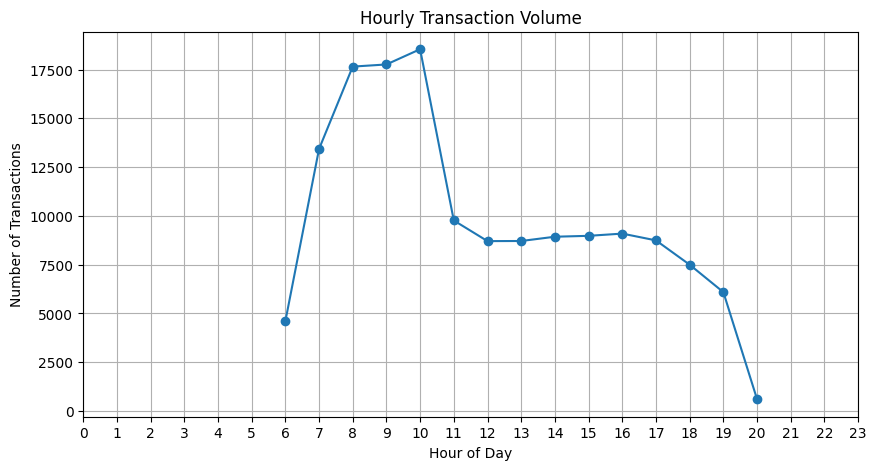

In [24]:
#Hourly Transaction volume
import pandas as pd
import matplotlib.pyplot as plt

hourly_transactions = df.groupby('hour')['transaction_id'].count()

# Plot hourly transaction volume
plt.figure(figsize=(10,5))
hourly_transactions.plot(kind='line', marker='o', title='Hourly Transaction Volume')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

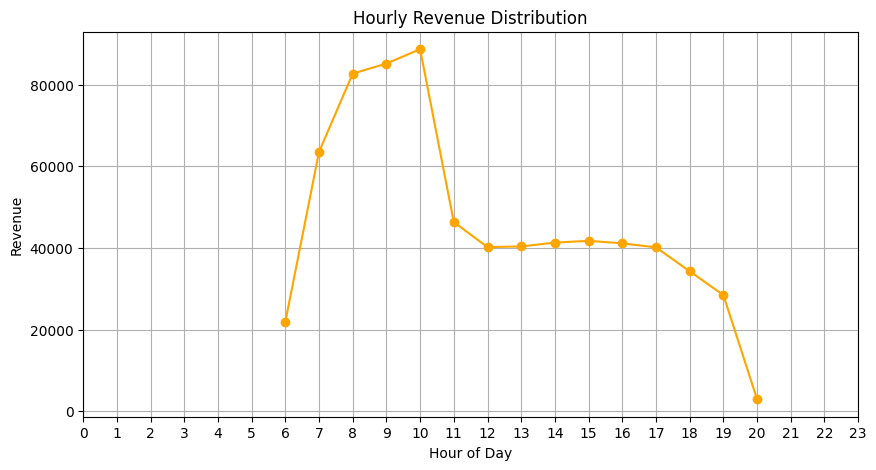

In [25]:
#Hourly Revenue Distribution
hourly_revenue = df.groupby('hour')['revenue'].sum()

# Plot hourly revenue
plt.figure(figsize=(10,5))
hourly_revenue.plot(kind='line', marker='o', color='orange', title='Hourly Revenue Distribution')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

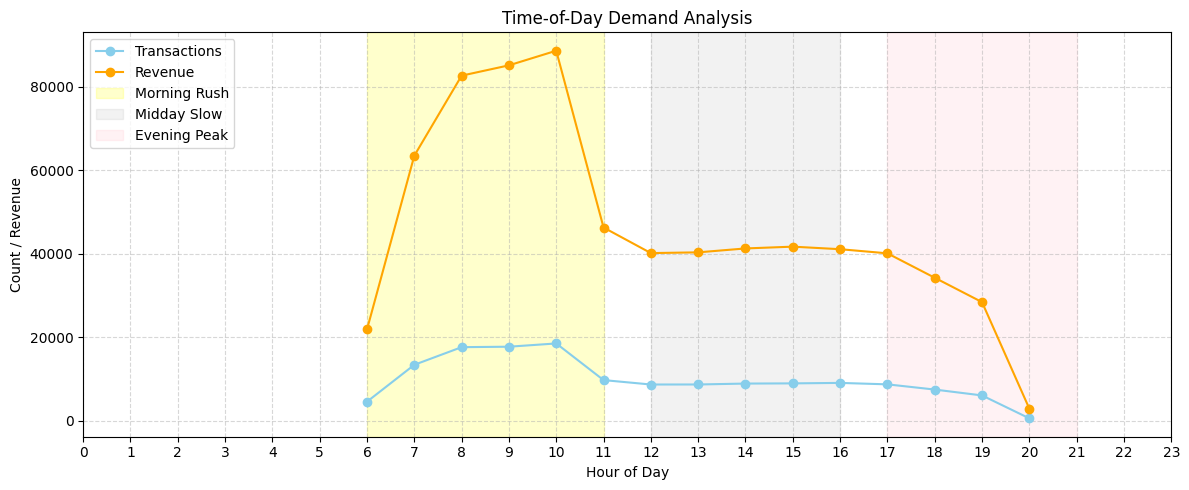

In [26]:
#Identification of: Morning rush hours,Midday slow periods,evening peaks

# Calculate hourly transaction volume and revenue if not already defined
hourly_transactions = df.groupby('hour')['transaction_id'].count()
hourly_revenue = df.groupby('hour')['revenue'].sum()

plt.figure(figsize=(12,5))

plt.plot(hourly_transactions.index, hourly_transactions.values, marker='o', linestyle='-', color='skyblue', label='Transactions')
plt.plot(hourly_revenue.index, hourly_revenue.values, marker='o', linestyle='-', color='orange', label='Revenue')

# Highlight periods
plt.axvspan(6,11, color='yellow', alpha=0.2, label='Morning Rush')
plt.axvspan(12,16, color='gray', alpha=0.1, label='Midday Slow')
plt.axvspan(17,21, color='pink', alpha=0.2, label='Evening Peak')

plt.title('Time-of-Day Demand Analysis')
plt.xlabel('Hour of Day')
plt.ylabel('Count / Revenue')
plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Cross-Location Temporal Comparison**

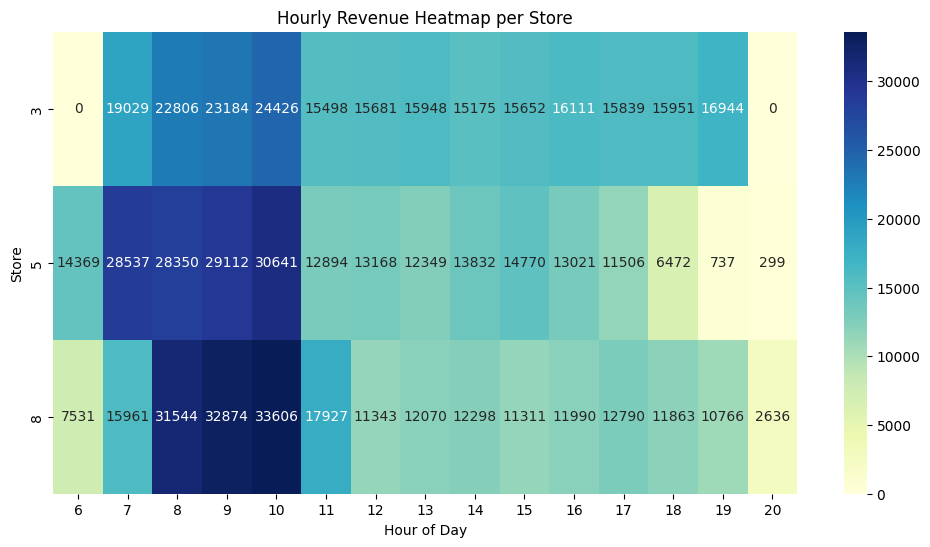

In [27]:
#Hourly heatmaps per store

# Aggregate revenue per store per hour
hourly_data = df.groupby(['store_id', 'hour'])['revenue'].sum().unstack(fill_value=0)

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(hourly_data, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Hourly Revenue Heatmap per Store')
plt.xlabel('Hour of Day')
plt.ylabel('Store')
plt.show()

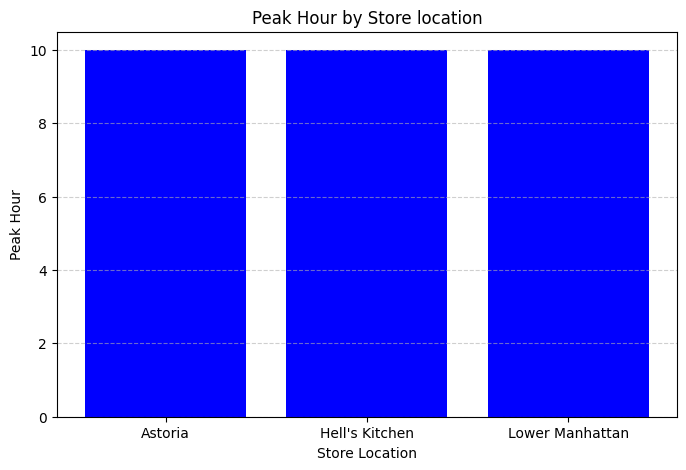

In [28]:
#Peak-hour alignment or divergence across locations

# Calculate hourly revenue for each store location
store_hourly_revenue_agg = df.groupby(['store_location', 'hour'])['revenue'].sum().reset_index()

# Find the peak hour (hour with max revenue) for each store
peak_hours = store_hourly_revenue_agg.loc[store_hourly_revenue_agg.groupby('store_location')['revenue'].idxmax()]

plt.figure(figsize=(8,5))
plt.bar(peak_hours['store_location'], peak_hours['hour'], color='b')
plt.title('Peak Hour by Store location')
plt.xlabel('Store Location')
plt.ylabel('Peak Hour')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

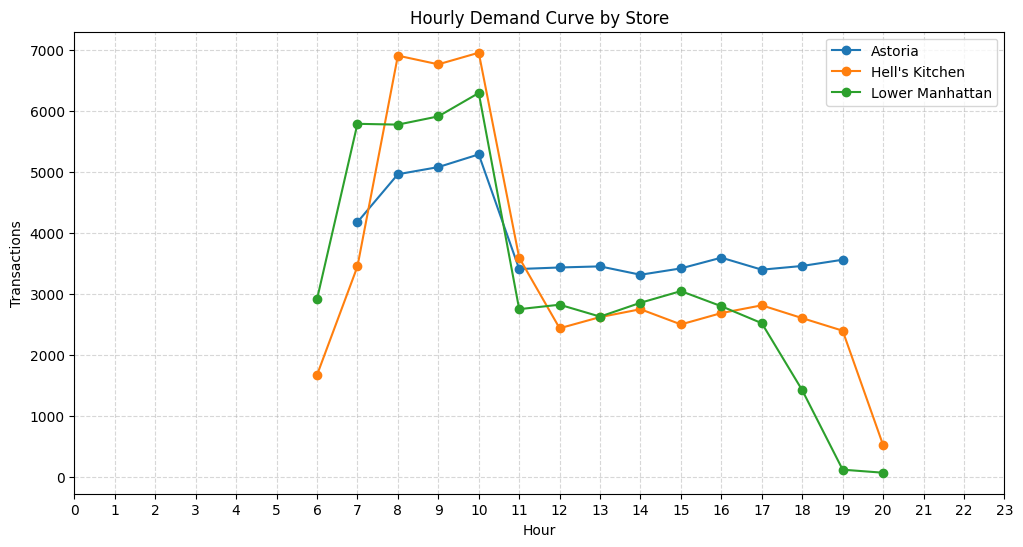

In [29]:
# --- 5. Location-specific customer behavior insights ---
store_hourly = df.groupby(['store_location','hour'])['transaction_id'].count().reset_index()

plt.figure(figsize=(12,6))

for store in store_hourly['store_location'].unique():
    data = store_hourly[store_hourly['store_location']==store]
    plt.plot(data['hour'], data['transaction_id'], marker='o', label=store)

plt.title('Hourly Demand Curve by Store')
plt.xlabel('Hour')
plt.ylabel('Transactions')
plt.xticks(range(0,24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()